# Pretrain on MPOSE2021 → Fine-tune on Reference Dances

**전체 파이프라인** (한 노트북에서 끝까지):

1. **데이터 준비** — MPOSE2021 다운로드 + 12 DANCE_JOINTS로 변환 + 캐시 저장
2. **Pretrain (6개)** — {MLP, TCN, GCN} × {small, base}을 MPOSE2021에 Supervised Contrastive(SupCon)으로 사전학습
3. **Fine-tune (12개 → )** — {MLP, TCN, GCN} × {small, base} × {InfoNCE, Triplet}로 파인튜닝. 각 variant는 같은 사이즈의 pretrain weights를 로드
4. **Compare vs scratch** — `scratch_contrastive_training` 노트북에서 미리 학습해둔 12개 scratch 모델을 디스크에서 로드해 finetune 결과와 나란히 비교

**목표**: pretrained 쪽이 (a) 더 빨리 수렴하거나 (b) 최종 val_loss가 더 좋거나 (c) within-dance 구분이 더 정밀해지는지 확인.

**사이즈 정의** (scratch_contrastive_training과 동일):
- `small`: `mlp_hidden=64 / tcn_filters=32,blocks=3 / gcn_filters=32,blocks=2`, `embedding_dim=32`
- `base`:  `mlp_hidden=128 / tcn_filters=64,blocks=4 / gcn_filters=64,blocks=3`, `embedding_dim=64`

아키텍처를 scratch와 정확히 맞추면 weight 1:1 이식 및 apples-to-apples 비교가 가능하다.

## 0. 환경 설정

In [1]:
import ctypes, glob, os
_nv = '/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/nvidia'
if os.path.isdir(_nv):
    for _so in sorted(glob.glob(f'{_nv}/*/lib/*.so.*')):
        try: ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except OSError: pass

import json, sys, time, itertools
from argparse import Namespace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
PROJECT_ROOT = None
for base in [start, *start.parents]:
    if (base / 'data' / 'reference_dances').exists() and (base / 'scripts' / 'prepare_mpose2021.py').exists():
        PROJECT_ROOT = base; break
if PROJECT_ROOT is None:
    raise RuntimeError('project root not found')
sys.path.insert(0, str(PROJECT_ROOT))

from src.embedding.dataset_contrastive import TARGET_DANCES
from scripts.prepare_mpose2021 import prepare as prepare_mpose
from scripts.pretrain_scratch_mpose2021 import train as pretrain_train
from scripts.train_scratch_contrastive import train as scratch_train

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('PROJECT_ROOT:', PROJECT_ROOT)
print('TF version  :', tf.__version__)
print('GPU devices :', gpus if gpus else 'NONE (CPU fallback)')

I0000 00:00:1776694228.649260 1851718 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PROJECT_ROOT: /workspace/users/yijin/boot_env/pjt_re
TF version  : 2.21.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. MPOSE2021 다운로드 + 전처리

`mpose` 패키지로 다운로드(최초 실행만; 이후엔 캐시) → COCO17→DANCE_JOINTS 재매핑 → T=30 pad/crop → 원시 xy 저장.

정규화는 pretrain 시점에 `normalize_pose`로 적용 (fine-tune과 일치시키기 위함).

출력: `data/pretrain/mpose2021/mpose2021_posenet_split1_raw.npz`

In [2]:
POSE_EXTRACTOR = 'posenet'   # 'posenet', 'openpose', or 'movenet'
SPLIT = 1
SEQUENCE_LENGTH = 30

cache_path = prepare_mpose(
    extractor=POSE_EXTRACTOR, split=SPLIT,
    sequence_length=SEQUENCE_LENGTH, overwrite=False,
)
print('cache at:', cache_path)

d = np.load(cache_path)
print(f"  train: {d['train_windows'].shape}, {len(np.unique(d['train_labels']))} classes")
print(f"  val  : {d['val_windows'].shape}")
print(f"  class distribution: {dict(zip(*np.unique(d['train_labels'], return_counts=True)))}")

[LOAD] cache already exists: /workspace/users/yijin/boot_env/pjt_re/data/pretrain/mpose2021/mpose2021_posenet_split1_raw.npz
cache at: /workspace/users/yijin/boot_env/pjt_re/data/pretrain/mpose2021/mpose2021_posenet_split1_raw.npz
  train: (12562, 30, 12, 2), 20 classes
  val  : (2867, 30, 12, 2)
  class distribution: {0: 426, 1: 199, 2: 288, 3: 241, 4: 298, 5: 241, 6: 227, 7: 1872, 8: 1070, 9: 1537, 10: 300, 11: 419, 12: 197, 13: 369, 14: 1441, 15: 1826, 16: 550, 17: 204, 18: 243, 19: 614}


## 2. Pretrain (SupCon on MPOSE2021)

MLP/TCN/GCN 각 1개씩 사전학습. `enabled=False`로 하면 skip. CPU 기준 한 모델당 ~5-15분(데이터 3000개, 50 epoch).

저장 위치: `data/models/pretrain/mpose2021/mpose_{model}_e{dim}.weights.h5`

In [3]:
# 사이즈별 아키텍처 kwargs (scratch_contrastive_training과 동일)
SIZES = {
    'small': dict(mlp_hidden=64,  tcn_filters=32, tcn_blocks=3,
                  gcn_filters=32, gcn_blocks=2, embedding_dim=32),
    'base':  dict(mlp_hidden=128, tcn_filters=64, tcn_blocks=4,
                  gcn_filters=64, gcn_blocks=3, embedding_dim=64),
}

PRETRAIN_COMMON = dict(
    data_path=str(cache_path),
    pose_extractor=POSE_EXTRACTOR, split=SPLIT, sequence_length=SEQUENCE_LENGTH,
    prepare_if_missing=False,
    output_dir='data/models/pretrain/mpose2021',
    dropout=0.15,
    epochs=50,
    batch_size=128,
    learning_rate=1e-3,
    min_learning_rate=1e-5,
    warmup_epochs=3,
    patience=10,
    temperature=0.1,
    tcn_kernel=3,
    gcn_kernel=9, gcn_partition='distance',
    runtime_jitter=0.005,      # Gaussian σ on every training sample
    augment_rot_deg=10.0,      # max ±deg random rotation per sample
    seed=42,
    verbose=2,
)

# 3 archs × 2 sizes = 6 pretrains
PRETRAIN_VARIANTS = [
    {'enabled': True, 'model': m, 'size': s}
    for m in ('mlp', 'tcn', 'gcn') for s in ('small', 'base')
]


def _size_kwargs(model, size):
    s = SIZES[size]
    k = {'embedding_dim': s['embedding_dim']}
    if model == 'mlp':
        k['mlp_hidden'] = s['mlp_hidden']
    elif model == 'tcn':
        k.update(tcn_filters=s['tcn_filters'], tcn_blocks=s['tcn_blocks'])
    else:
        k.update(gcn_filters=s['gcn_filters'], gcn_blocks=s['gcn_blocks'])
    return k


def run_pretrain(variant):
    cfg = {**PRETRAIN_COMMON, 'model': variant['model']}
    cfg.update(_size_kwargs(variant['model'], variant['size']))
    cfg['model_name'] = f"mpose_{variant['model']}_{variant['size']}_e{cfg['embedding_dim']}"
    # pretrain script doesn't have size-specific kwargs absent; fill unused defaults
    for k, default in [('mlp_hidden', 256), ('tcn_filters', 96), ('tcn_blocks', 4),
                       ('gcn_filters', 64), ('gcn_blocks', 3)]:
        cfg.setdefault(k, default)
    return pretrain_train(Namespace(**cfg))


print('Pretrain plan:')
for v in PRETRAIN_VARIANTS:
    mark = 'ON ' if v.get('enabled', True) else 'off'
    name = f"mpose_{v['model']}_{v['size']}_e{SIZES[v['size']]['embedding_dim']}"
    print(f"  [{mark}] {v['model']:3s}/{v['size']:5s} -> {name}")


Pretrain plan:
  [ON ] mlp/small -> mpose_mlp_small_e32
  [ON ] mlp/base  -> mpose_mlp_base_e64
  [ON ] tcn/small -> mpose_tcn_small_e32
  [ON ] tcn/base  -> mpose_tcn_base_e64
  [ON ] gcn/small -> mpose_gcn_small_e32
  [ON ] gcn/base  -> mpose_gcn_base_e64


In [4]:
pretrain_results = {}  # key: (model, size) -> result dict
enabled = [v for v in PRETRAIN_VARIANTS if v.get('enabled', True)]
for i, v in enumerate(enabled):
    key = (v['model'], v['size'])
    name = f"mpose_{v['model']}_{v['size']}_e{SIZES[v['size']]['embedding_dim']}"
    print(f"\n{'='*70}\n[PRETRAIN {i+1}/{len(enabled)}] {name}\n{'='*70}")
    t0 = time.time()
    pretrain_results[key] = run_pretrain(v)
    print(f"  done in {time.time()-t0:.1f}s")

pretrain_paths = {k: r['paths']['weights'] for k, r in pretrain_results.items()}
print('\nPretrained encoder weights:')
for (m, s), p in pretrain_paths.items():
    print(f'  {m}/{s}: {p}')


[PRETRAIN 1/6] mpose_mlp_small_e32
[NORM] applying hip/torso normalization...
[DATA] train=12562, val=2867, T=30, J=12, C=2, num_classes=20


I0000 00:00:1776694232.803538 1851718 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2331 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:0a:00.0, compute capability: 8.6


Model: "scratch_mlp_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pose (InputLayer)               │ (None, 30, 12, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_joints (Reshape)        │ (None, 30, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_1 (Dense)           │ (None, 30, 64)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_1 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_1 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_1 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_2 (Dense)           │ (None, 30, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_2 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_2 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_2 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool                   │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_hidden (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_raw (Dense)           │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Lambda)              │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,408 (36.75 KB)

...

 Trainable params: 157,632 (615.75 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50


I0000 00:00:1776694446.461825 1851881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_175941__.105
I0000 00:00:1776694454.727883 1851881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_177056__.12


98/98 - 14s - 145ms/step - class_retrieval_acc: 0.5281 - loss: 4.0473 - val_class_retrieval_acc: 0.8022 - val_loss: 4.7040 - learning_rate: 3.3333e-04
Epoch 2/50
98/98 - 2s - 18ms/step - class_retrieval_acc: 0.6153 - loss: 3.6866 - val_class_retrieval_acc: 0.8026 - val_loss: 4.4974 - learning_rate: 6.6667e-04
Epoch 3/50
98/98 - 2s - 18ms/step - class_retrieval_acc: 0.6281 - loss: 3.5671 - val_class_retrieval_acc: 0.8327 - val_loss: 4.2327 - learning_rate: 0.0010
Epoch 4/50
98/98 - 2s - 18ms/step - class_retrieval_acc: 0.6468 - loss: 3.4741 - val_class_retrieval_acc: 0.8576 - val_loss: 4.0656 - learning_rate: 0.0010
Epoch 5/50
98/98 - 2s - 18ms/step - class_retrieval_acc: 0.6565 - loss: 3.4051 - val_class_retrieval_acc: 0.8590 - val_loss: 3.9208 - learning_rate: 9.9889e-04
Epoch 6/50
98/98 - 2s - 18ms/step - class_retrieval_acc: 0.6707 - loss: 3.3577 - val_class_retrieval_acc: 0.8619 - val_loss: 3.8935 - learning_rate: 9.9558e-04
Epoch 7/50
98/98 - 2s - 17ms/step - class_retrieval_acc: 

## 3. Fine-tune (로드한 weights로 scratch 파이프라인)

Pretrain 대비 차이:
- LR: 1e-3 → **1e-4** (pretrained feature 보호)
- Epochs: 50 → **20**
- Warmup: 3 → **1** (이미 합리적 초기화니까)
- `pretrained_weights` 경로 전달

나머지(batch, augment, InfoNCE 등)는 scratch와 완전 동일.

In [5]:
FINETUNE_COMMON = dict(
    data_dir='data/reference_dances',
    dances=list(TARGET_DANCES),
    output_dir='data/models/embedding',
    feature_dims=2,
    sequence_length=SEQUENCE_LENGTH,
    val_fraction=0.15,
    dropout=0.15,
    epochs=50,                    # shorter than scratch's 50
    steps_per_epoch=200,
    validation_steps=30,
    batch_size=128,
    learning_rate=1e-4,           # 10x lower than scratch's 1e-3
    min_learning_rate=1e-6,
    warmup_epochs=1,              # shorter than scratch's 3
    patience=8,
    temperature=0.1,
    triplet_margin=0.2,
    positive_jitter=2,
    negative_gap=300,
    runtime_jitter=0.005,
    tcn_kernel=3,
    gcn_kernel=9, gcn_partition='distance',
    seed=42,
    no_quantize=False,
    keep_checkpoint=False,
    verbose=2,
)

# 3 archs × 2 sizes × 2 losses = 12 finetunes
FINETUNE_VARIANTS = [
    {'enabled': True, 'model': m, 'size': s, 'loss': l}
    for m in ('mlp', 'tcn', 'gcn')
    for s in ('small', 'base')
    for l in ('infonce', 'triplet')
]


def run_finetune(variant, pretrained_path):
    cfg = {**FINETUNE_COMMON, 'model': variant['model'], 'loss': variant['loss']}
    cfg.update(_size_kwargs(variant['model'], variant['size']))
    # Fill unused size kwargs with harmless defaults (scratch_train expects them)
    for k, default in [('mlp_hidden', 128), ('tcn_filters', 64), ('tcn_blocks', 4),
                       ('gcn_filters', 64), ('gcn_blocks', 3)]:
        cfg.setdefault(k, default)
    cfg['model_name'] = (f"finetune_{variant['model']}_{variant['size']}_"
                        f"{variant['loss']}_e{cfg['embedding_dim']}")
    cfg['pretrained_weights'] = pretrained_path
    return scratch_train(Namespace(**cfg))


print(f"Fine-tune plan ({len(FINETUNE_VARIANTS)} variants):")
print(f"{'idx':>3} | {'model':>5} | {'size':>5} | {'loss':>7} | {'dim':>3} | pretrained")
print('-' * 70)
for i, v in enumerate(FINETUNE_VARIANTS):
    key = (v['model'], v['size'])
    pname = Path(pretrain_paths[key]).name if key in pretrain_paths else '(missing)'
    dim = SIZES[v['size']]['embedding_dim']
    print(f"{i:>3} | {v['model']:>5} | {v['size']:>5} | {v['loss']:>7} | {dim:>3} | {pname}")


Fine-tune plan (12 variants):
idx | model |  size |    loss | dim | pretrained
----------------------------------------------------------------------
  0 |   mlp | small | infonce |  32 | mpose_mlp_small_e32.weights.h5
  1 |   mlp | small | triplet |  32 | mpose_mlp_small_e32.weights.h5
  2 |   mlp |  base | infonce |  64 | mpose_mlp_base_e64.weights.h5
  3 |   mlp |  base | triplet |  64 | mpose_mlp_base_e64.weights.h5
  4 |   tcn | small | infonce |  32 | mpose_tcn_small_e32.weights.h5
  5 |   tcn | small | triplet |  32 | mpose_tcn_small_e32.weights.h5
  6 |   tcn |  base | infonce |  64 | mpose_tcn_base_e64.weights.h5
  7 |   tcn |  base | triplet |  64 | mpose_tcn_base_e64.weights.h5
  8 |   gcn | small | infonce |  32 | mpose_gcn_small_e32.weights.h5
  9 |   gcn | small | triplet |  32 | mpose_gcn_small_e32.weights.h5
 10 |   gcn |  base | infonce |  64 | mpose_gcn_base_e64.weights.h5
 11 |   gcn |  base | triplet |  64 | mpose_gcn_base_e64.weights.h5


In [6]:
finetune_results = {}  # key: (model, size, loss) -> result dict
enabled = [v for v in FINETUNE_VARIANTS if v.get('enabled', True)]
for i, v in enumerate(enabled):
    key = (v['model'], v['size'], v['loss'])
    pretrained_key = (v['model'], v['size'])
    if pretrained_key not in pretrain_paths:
        print(f"[SKIP] {key}: no pretrain for {pretrained_key}")
        continue
    dim = SIZES[v['size']]['embedding_dim']
    name = f"finetune_{v['model']}_{v['size']}_{v['loss']}_e{dim}"
    print(f"\n{'='*70}\n[FINETUNE {i+1}/{len(enabled)}] {name}\n{'='*70}")
    t0 = time.time()
    finetune_results[key] = run_finetune(v, pretrain_paths[pretrained_key])
    print(f"  done in {time.time()-t0:.1f}s")

print(f"\n{len(finetune_results)}/{len(enabled)} finetunes completed")


[FINETUNE 1/12] finetune_mlp_small_infonce_e32
[404_dance] T=568, augments=30
[basic_movement] T=476, augments=30
[beginner_wave] T=679, augments=30
[cheerup_dance] T=724, augments=30
[hiphop_move] T=792, augments=30
[kpop_basic] T=7164, augments=30
[rasputin] T=3147, augments=30
[shuffle_dance] T=1538, augments=30
[DATA] 8 dances, feature_dims=2, val_fraction=0.15
[FINETUNE] loaded pretrained weights from /workspace/users/yijin/boot_env/pjt_re/data/models/pretrain/mpose2021/mpose_mlp_small_e32.weights.h5


Model: "scratch_mlp_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pose (InputLayer)               │ (None, 30, 12, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_joints (Reshape)        │ (None, 30, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_1 (Dense)           │ (None, 30, 64)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_1 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_1 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_1 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_dense_2 (Dense)           │ (None, 30, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_bn_2 (BatchNormalization) │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_relu_2 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_drop_2 (Dropout)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool                   │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_hidden (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_raw (Dense)           │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Lambda)              │ (None, 32)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,408 (36.75 KB)

 Trainable params: 9,152 (35.75 KB)

...

I0000 00:00:1776695634.546249 1851881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_681085__.237
I0000 00:00:1776695652.838851 1851880 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_683298__.12


200/200 - 28s - 139ms/step - loss: 0.0041 - pos_margin: 0.6350 - val_loss: 0.0108 - val_pos_margin: 0.6764 - val_violation_rate: 0.1018 - violation_rate: 0.0505 - learning_rate: 1.0000e-04
Epoch 2/50
200/200 - 9s - 47ms/step - loss: 0.0014 - pos_margin: 0.7235 - val_loss: 0.0072 - val_pos_margin: 0.7382 - val_violation_rate: 0.0661 - violation_rate: 0.0217 - learning_rate: 1.0000e-04
Epoch 3/50
200/200 - 9s - 47ms/step - loss: 8.5775e-04 - pos_margin: 0.7740 - val_loss: 0.0056 - val_pos_margin: 0.7829 - val_violation_rate: 0.0477 - violation_rate: 0.0125 - learning_rate: 9.9898e-05
Epoch 4/50
200/200 - 9s - 47ms/step - loss: 4.7354e-04 - pos_margin: 0.8096 - val_loss: 0.0047 - val_pos_margin: 0.8336 - val_violation_rate: 0.0414 - violation_rate: 0.0075 - learning_rate: 9.9594e-05
Epoch 5/50
200/200 - 9s - 47ms/step - loss: 4.1358e-04 - pos_margin: 0.8307 - val_loss: 0.0051 - val_pos_margin: 0.8153 - val_violation_rate: 0.0404 - violation_rate: 0.0066 - learning_rate: 9.9087e-05
Epoch 6

I0000 00:00:1776695824.128370 1851718 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1776695824.128475 1851718 single_machine.cc:376] Starting new session
I0000 00:00:1776695824.134659 1851718 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2331 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:0a:00.0, compute capability: 8.6
W0000 00:00:1776695824.282487 1851718 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776695824.282509 1851718 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


[SAVE] encoder  : /workspace/users/yijin/boot_env/pjt_re/data/models/embedding/finetune_gcn_base_triplet_e64_encoder.keras
[SAVE] tflite   : /workspace/users/yijin/boot_env/pjt_re/data/models/embedding/finetune_gcn_base_triplet_e64.tflite (188.4 KiB)
[SAVE] metadata : /workspace/users/yijin/boot_env/pjt_re/data/models/embedding/finetune_gcn_base_triplet_e64_meta.json
  done in 198.5s

12/12 finetunes completed


I0000 00:00:1776695824.341819 1851718 flatbuffer_export.cc:4302] Estimated count of arithmetic ops: 111.899 M  ops, equivalently 55.949 M  MACs


## 4. Scratch 결과 로드 (대조군)

`scratch_contrastive_training` 노트북에서 미리 학습해둔 12개 scratch 모델을 디스크에서 로드.
- 위치: `data/models/scratch/scratch_{model}_{size}_{loss}_e{dim}_meta.json` + `.tflite`
- 로드 항목: history (loss/metric 곡선), tflite path, 파라미터 수

scratch_contrastive_training을 먼저 실행해서 12개가 모두 존재해야 비교가 완전해진다.

In [7]:
SCRATCH_DIR = PROJECT_ROOT / 'data' / 'models' / 'scratch'


def _load_scratch(variant):
    """Load a previously-trained scratch model's meta + tflite path.

    Returns a dict shaped similarly to `scratch_train()` output so the rest
    of the notebook can treat scratch/finetune interchangeably.
    """
    dim = SIZES[variant['size']]['embedding_dim']
    name = f"scratch_{variant['model']}_{variant['size']}_{variant['loss']}_e{dim}"
    meta_p = SCRATCH_DIR / f"{name}_meta.json"
    tflite_p = SCRATCH_DIR / f"{name}.tflite"
    keras_p = SCRATCH_DIR / f"{name}_encoder.keras"
    if not meta_p.exists() or not tflite_p.exists():
        return None
    meta = json.loads(meta_p.read_text())
    return {
        'history': meta.get('history', {}),
        'tflite_size_kib': meta.get('tflite_size_kib',
                                     tflite_p.stat().st_size / 1024.0),
        'paths': {'tflite': str(tflite_p), 'keras': str(keras_p),
                  'meta': str(meta_p)},
        'meta': meta,
    }


scratch_results = {}    # key: (model, size, loss) -> dict
missing = []
for v in FINETUNE_VARIANTS:
    key = (v['model'], v['size'], v['loss'])
    r = _load_scratch(v)
    if r is None:
        missing.append(key)
        continue
    scratch_results[key] = r

print(f"Scratch loaded: {len(scratch_results)}/{len(FINETUNE_VARIANTS)}")
if missing:
    print('\n[!] Missing scratch models:')
    for k in missing:
        print(f'    {k}  — run scratch_contrastive_training.ipynb first')

Scratch loaded: 12/12


## 5. 비교 분석

- **Loss 곡선** (train + val): pretrained 쪽이 더 빨리 내려가는지
- **최종 val_loss / val_retrieval_acc**: pretrained 쪽이 더 좋은지
- **Within-dance 구분**: 같은 곡에서 가까운-시점 vs 먼-시점 margin 차이
- **Epochs to early stop**: pretrained 쪽이 더 일찍 수렴하는지

In [8]:
def _final(history, keys):
    for k in keys:
        if k in history and history[k]:
            return history[k][-1]
    return float('nan')


def _params_from_tflite_size_kib(kib):
    # Rough: quantized weights ≈ 1 byte/param (dynamic range int8). Not exact, but
    # useful as a rank. Accurate param counts require loading the .keras model.
    return int(kib * 1024)


rows = []
for v in FINETUNE_VARIANTS:
    key = (v['model'], v['size'], v['loss'])
    pairs = [('finetune', finetune_results.get(key)),
             ('scratch',  scratch_results.get(key))]
    for regime, res in pairs:
        if res is None:
            continue
        h = res['history']
        rows.append({
            'model': v['model'],
            'size': v['size'],
            'loss': v['loss'],
            'regime': regime,
            'tflite_KiB': round(res['tflite_size_kib'], 1),
            'val_loss': round(_final(h, ['val_loss']), 4),
            'val_metric': round(_final(h, ['val_retrieval_acc', 'val_pos_margin']), 4),
            'train_loss': round(_final(h, ['loss']), 4),
            'epochs_run': len(h.get('loss', [])),
        })

summary = pd.DataFrame(rows).sort_values(['model', 'size', 'loss', 'regime'])
summary


,model,size,loss,regime,tflite_KiB,val_loss,val_metric,train_loss,epochs_run
20,gcn,base,infonce,finetune,188.4,0.0947,1.0000,0.0216,20
21,gcn,base,infonce,scratch,188.4,0.1359,0.9961,0.0114,17
22,gcn,base,triplet,finetune,188.4,0.0047,0.9118,0.0001,19
23,gcn,base,triplet,scratch,188.4,0.0060,0.7995,0.0001,22
16,gcn,small,infonce,finetune,47.7,0.1020,1.0000,0.0503,39
17,gcn,small,infonce,scratch,47.7,0.1765,1.0000,0.0231,18
18,gcn,small,triplet,finetune,47.7,0.0059,0.9227,0.0004,15
19,gcn,small,triplet,scratch,47.7,0.0058,0.8976,0.0001,32
4,mlp,base,infonce,finetune,40.5,0.0732,0.9995,0.0219,42
5,mlp,base,infonce,scratch,40.5,0.1247,0.9992,0.0142,12


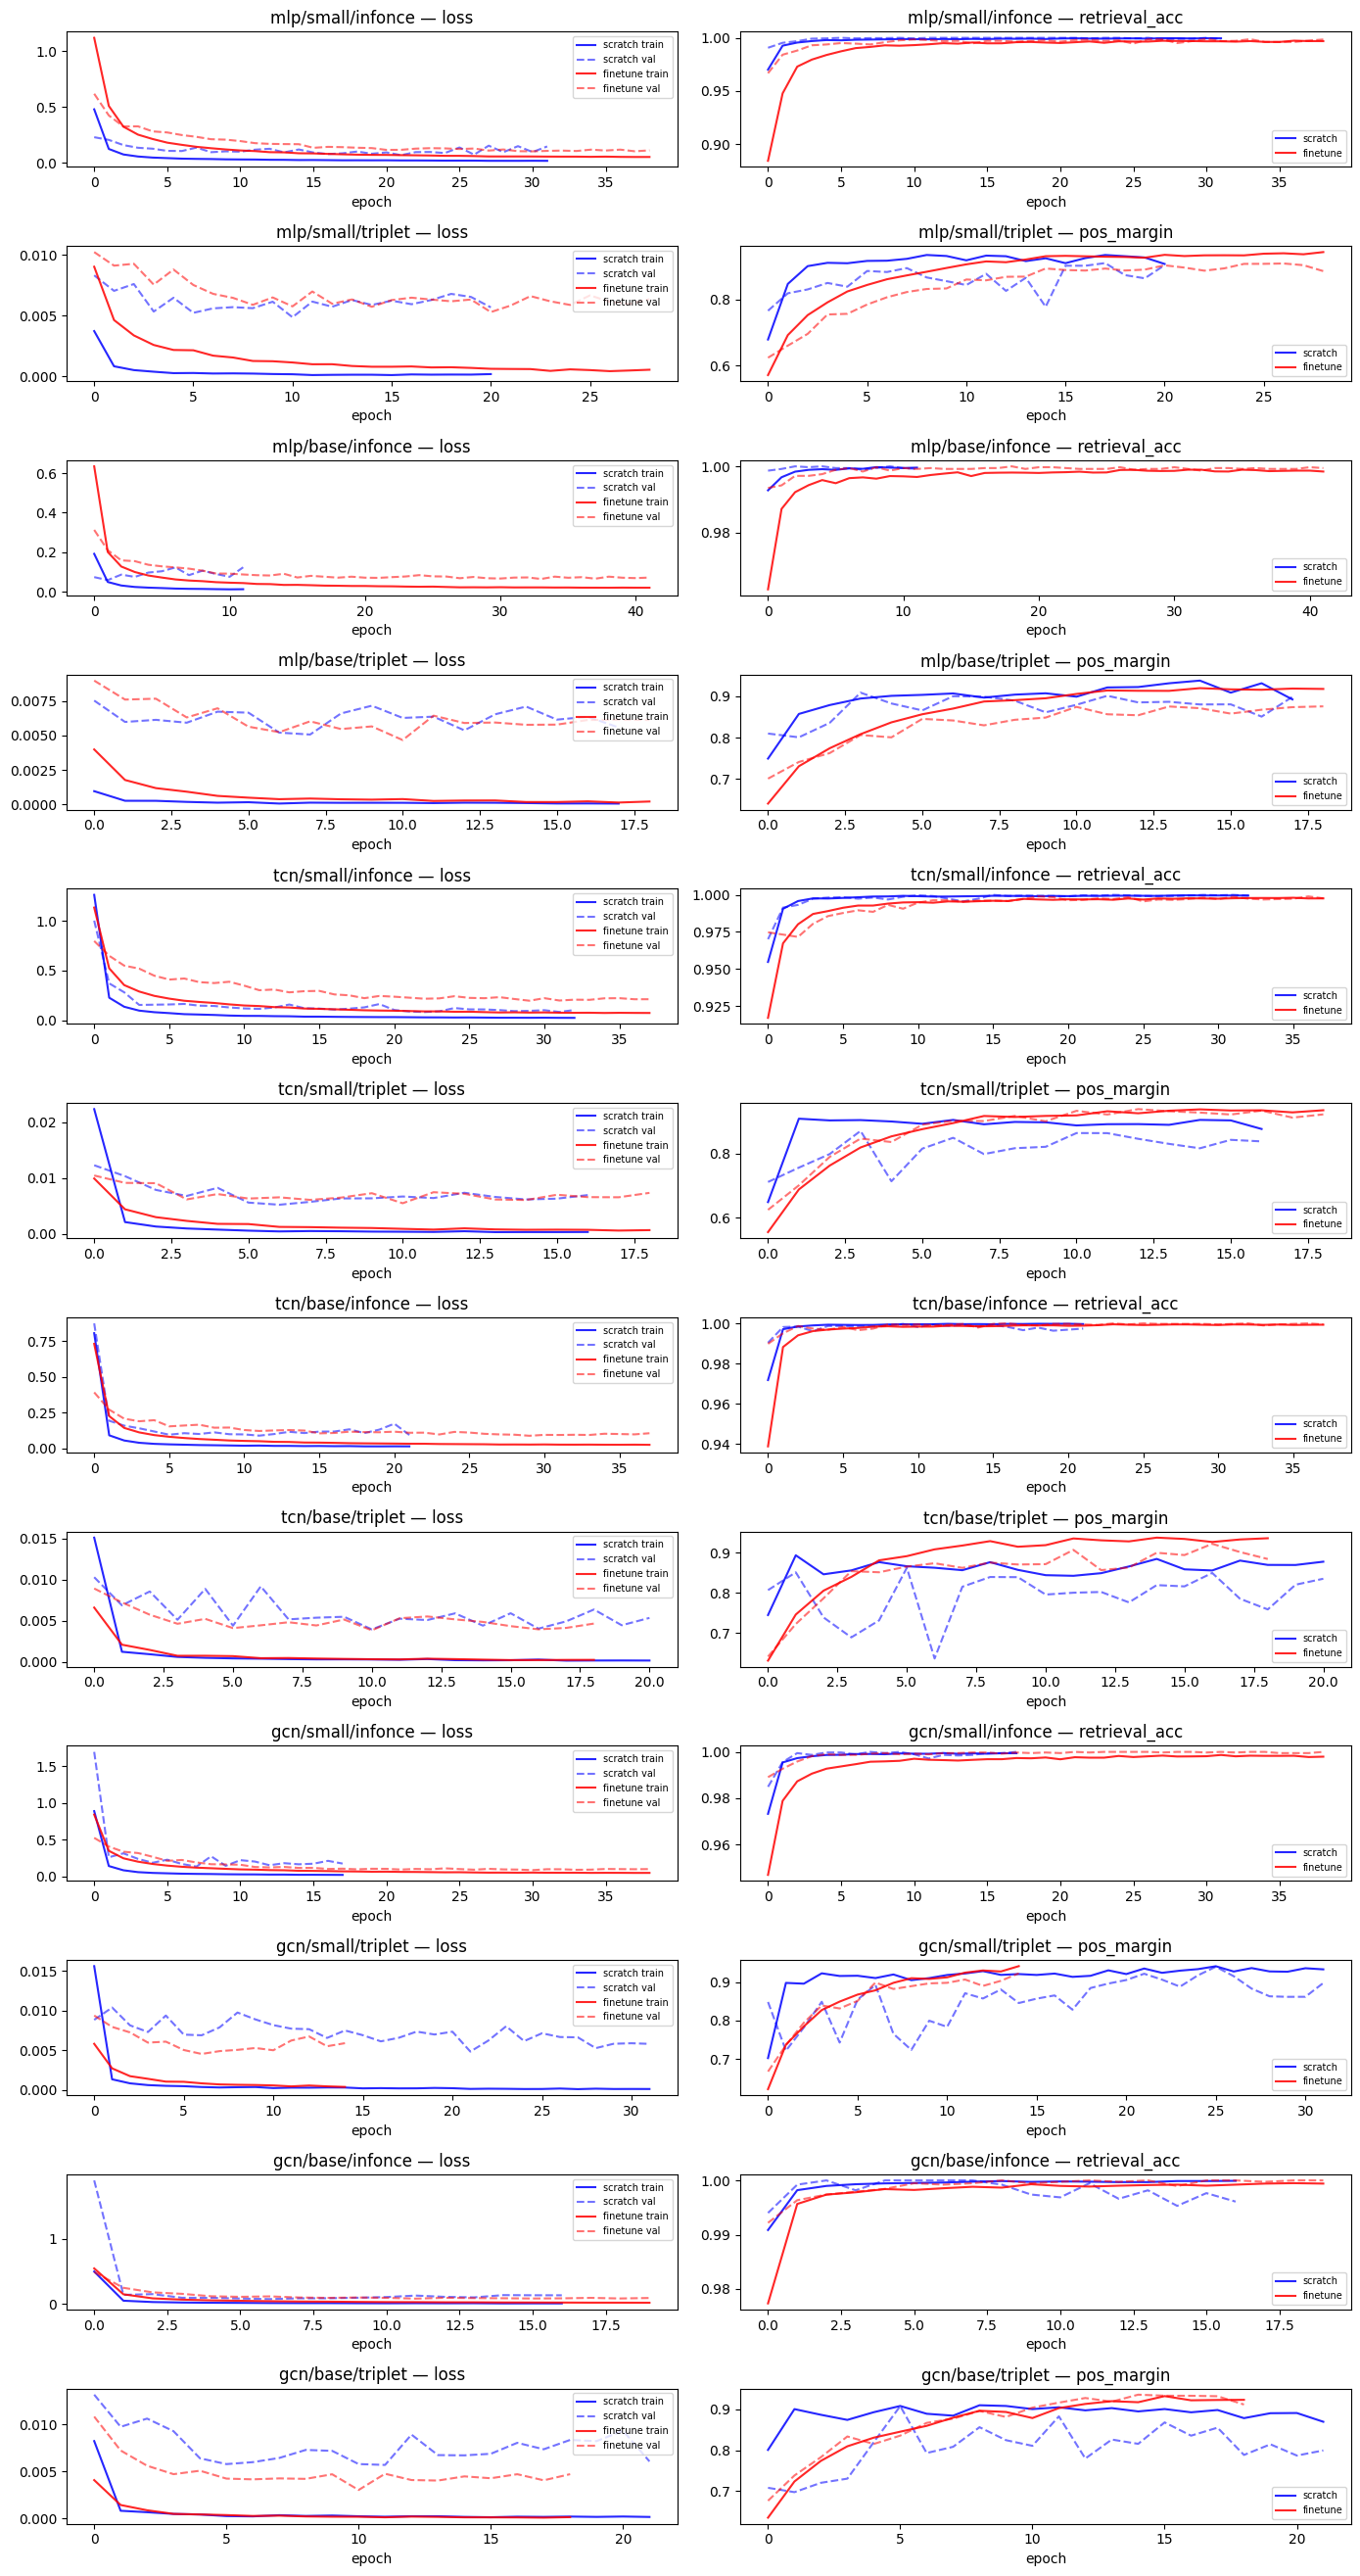

In [9]:
# 12 variants, 2 regimes each: 6 rows × 2 cols
fig, axes = plt.subplots(len(FINETUNE_VARIANTS), 2,
                          figsize=(14, 2.2 * len(FINETUNE_VARIANTS)))
if len(FINETUNE_VARIANTS) == 1:
    axes = axes[None, :]

for row, v in enumerate(FINETUNE_VARIANTS):
    key = (v['model'], v['size'], v['loss'])
    rf = finetune_results.get(key)
    rs = scratch_results.get(key)
    title = f"{v['model']}/{v['size']}/{v['loss']}"

    # Loss curves
    ax = axes[row, 0]
    if rs is not None:
        h = rs['history']
        ax.plot(h.get('loss', []), 'b-', label='scratch train', alpha=0.85)
        if 'val_loss' in h:
            ax.plot(h['val_loss'], 'b--', alpha=0.55, label='scratch val')
    if rf is not None:
        h = rf['history']
        ax.plot(h.get('loss', []), 'r-', label='finetune train', alpha=0.85)
        if 'val_loss' in h:
            ax.plot(h['val_loss'], 'r--', alpha=0.55, label='finetune val')
    ax.set_title(f'{title} — loss'); ax.set_xlabel('epoch')
    ax.legend(fontsize=7, loc='upper right')

    # Metric curves
    ax = axes[row, 1]
    metric = 'retrieval_acc' if v['loss'] == 'infonce' else 'pos_margin'
    val_metric = f'val_{metric}'
    if rs is not None:
        h = rs['history']
        if metric in h:
            ax.plot(h[metric], 'b-', label='scratch', alpha=0.85)
        if val_metric in h:
            ax.plot(h[val_metric], 'b--', alpha=0.55)
    if rf is not None:
        h = rf['history']
        if metric in h:
            ax.plot(h[metric], 'r-', label='finetune', alpha=0.85)
        if val_metric in h:
            ax.plot(h[val_metric], 'r--', alpha=0.55)
    ax.set_title(f'{title} — {metric}'); ax.set_xlabel('epoch')
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout(); plt.show()

## 6. Within-dance 구분력 비교 (핵심 지표)

Scratch 학습의 약점이었던 **"같은 곡의 다른 시점" 구분력**을 직접 측정. 같은 곡의 close-t vs far-t pair에 대해 cosine similarity 차이를 계산.

- `close_t`: anchor와 positive 시점이 거의 같음 (|Δt|<2) — **가까워야**
- `far_t` (same song): anchor와 다른 시점 — **멀어야** (이게 scratch의 약점)
- `far_song`: 다른 곡 — **아주 멀어야** (scratch가 이미 잘하는 부분)

In [10]:
from src.embedding.dataset_contrastive import ContrastiveSequenceStore

store = ContrastiveSequenceStore(PROJECT_ROOT / 'data' / 'reference_dances',
                                 dances=TARGET_DANCES, feature_dims=2, verbose=False)


def tflite_embed(tflite_path, x):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    idet = interp.get_input_details()[0]; odet = interp.get_output_details()[0]
    out = []
    for i in range(x.shape[0]):
        interp.set_tensor(idet['index'], x[i:i+1].astype(idet['dtype']))
        interp.invoke()
        out.append(interp.get_tensor(odet['index'])[0])
    return np.stack(out)


def sample_triples(store, T=30, n=64, seed=7777):
    rng = np.random.default_rng(seed)
    anchors, close_pos, far_same, far_other = [], [], [], []
    for _ in range(n):
        i = rng.integers(len(store))
        b = store.bundles[i]
        t = rng.integers(T-1, b.num_frames-1)
        a = b.original[t-T+1:t+1]
        if b.augments:
            aug = b.augments[rng.integers(len(b.augments))]
            p_close = aug[t-T+1:t+1]
        else:
            p_close = a
        for _try in range(30):
            t2 = rng.integers(T-1, b.num_frames-1)
            if abs(t2 - t) > 200:
                break
        n_same = b.original[t2-T+1:t2+1]
        other_idx = rng.choice([k for k in range(len(store)) if k != i])
        bo = store.bundles[other_idx]
        t3 = rng.integers(T-1, bo.num_frames-1)
        n_other = bo.original[t3-T+1:t3+1]
        anchors.append(a); close_pos.append(p_close)
        far_same.append(n_same); far_other.append(n_other)
    return (np.stack(anchors), np.stack(close_pos),
            np.stack(far_same), np.stack(far_other))


A, Pc, Ns, No = sample_triples(store, n=64)

rows = []
for v in FINETUNE_VARIANTS:
    key = (v['model'], v['size'], v['loss'])
    for regime, res in [('finetune', finetune_results.get(key)),
                        ('scratch',  scratch_results.get(key))]:
        if res is None:
            continue
        path = res['paths']['tflite']
        ea = tflite_embed(path, A); ep = tflite_embed(path, Pc)
        ens = tflite_embed(path, Ns); eno = tflite_embed(path, No)
        cos_close = float((ea * ep).sum(-1).mean())
        cos_far_same = float((ea * ens).sum(-1).mean())
        cos_far_other = float((ea * eno).sum(-1).mean())
        rows.append({
            'model': v['model'], 'size': v['size'], 'loss': v['loss'],
            'regime': regime,
            'cos(same_t)': round(cos_close, 3),
            'cos(same_song, far_t)': round(cos_far_same, 3),
            'cos(other_song)': round(cos_far_other, 3),
            'within_dance_margin': round(cos_close - cos_far_same, 3),
            'cross_dance_margin': round(cos_close - cos_far_other, 3),
        })
pd.DataFrame(rows).sort_values(['model', 'size', 'loss', 'regime'])

/workspace/users/yijin/boot_env/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,size,loss,regime,cos(same_t),"cos(same_song, far_t)",cos(other_song),within_dance_margin,cross_dance_margin
20,gcn,base,infonce,finetune,0.991,0.154,-0.022,0.837,1.013
21,gcn,base,infonce,scratch,0.990,0.203,-0.040,0.787,1.030
22,gcn,base,triplet,finetune,0.984,0.144,0.084,0.839,0.899
23,gcn,base,triplet,scratch,0.984,0.107,0.065,0.877,0.918
16,gcn,small,infonce,finetune,0.986,0.187,-0.027,0.799,1.013
17,gcn,small,infonce,scratch,0.986,0.140,-0.044,0.846,1.030
18,gcn,small,triplet,finetune,0.982,0.180,0.043,0.802,0.940
19,gcn,small,triplet,scratch,0.985,0.150,0.065,0.835,0.921
4,mlp,base,infonce,finetune,0.988,0.075,-0.043,0.914,1.031
5,mlp,base,infonce,scratch,0.982,0.131,-0.030,0.851,1.013


## 완료

**저장 아티팩트**:
- Pretrain (6개): `data/models/pretrain/mpose2021/mpose_{model}_{size}_e{dim}.weights.h5`
- Finetune (12개): `data/models/embedding/finetune_{model}_{size}_{loss}_e{dim}.{tflite,keras,meta.json}`
- Scratch (12개, 외부 입력): `data/models/scratch/scratch_{model}_{size}_{loss}_e{dim}.*` (scratch_contrastive_training에서 생성)

**해석 가이드**:
- `val_loss` 낮을수록 좋음 — finetune이 낮으면 pretrain이 효과적
- `within_dance_margin` 클수록 좋음 — scratch의 약점이었던 **같은 곡 다른 시점 구분**이 개선됐는지
- `cross_dance_margin`은 scratch가 이미 잘 하는 부분 (둘 다 크게 나옴)
- `epochs_run` — finetune이 더 일찍 수렴하면 pretrain 효과 있음

**서비스 배포 예시**:
```bash
python src/main.py -s embedding \\
    --compare data/reference_dances/rasputin/reference.npy \\
    --embedding-model-path data/models/embedding/finetune_tcn_base_infonce_e64.tflite \\
    --scratch-sequence-length 30 --scratch-feature-dims 2 --scratch-input-layout BTJC
```